In [9]:
# ============================================================
# DECISION TREE FROM SCRATCH
# ============================================================
# A Decision Tree is like a game of '20 Questions'!
#
# It asks a series of yes/no questions about the data:
#   'Is Feature 1 <= 2.5?'
#     YES -> 'Is Feature 2 <= 1.0?' -> ... -> Predict Class 0
#     NO  -> 'Is Feature 1 <= 4.0?' -> ... -> Predict Class 1
#
# The tree LEARNS which questions to ask from training data.
# Each question splits the data into two groups.
# We keep splitting until each group has only one class.
#
# ASCII Diagram of a Decision Tree:
#
#         [Feature 1 <= 2.5?]      <- Root node (first question)
#         /               \
#       YES                NO
#       /                    \
# [Feature 2 <= 1.0?]    [Class = 1]  <- Leaf (answer!)
#    /         \
#  YES          NO
#   |            |
# [Class=0]  [Class=1]             <- Leaf nodes
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print('=' * 60)
print('DECISION TREE FROM SCRATCH')
print('=' * 60)

# ============================================================
# STEP 1: MEASURING IMPURITY
# ============================================================
# Before building the tree, we need a way to measure how
# 'mixed up' (impure) a group of labels is.
#
# PURE group:   [0, 0, 0, 0, 0]  -> All same class -> Great!
# MIXED group:  [0, 0, 1, 1, 0]  -> Mixed classes  -> Bad!
#
# We use TWO measures of impurity:
#
# 1. ENTROPY: From information theory
#    - 0 = perfectly pure (all one class)
#    - 1 = maximally mixed (50/50 split)
#    - Formula: H = -sum( p_i * log2(p_i) )
#
# 2. GINI IMPURITY: Simpler and faster to compute
#    - 0 = perfectly pure
#    - 0.5 = maximally mixed
#    - Formula: G = 1 - sum( p_i^2 )
#
# ANALOGY: Think of a bag of colored balls.
#   Pure bag (all red):            entropy = 0
#   Mixed bag (50% red, 50% blue): entropy = 1
# ============================================================

def entropy(y):
    """
    Compute entropy of a set of labels.

    Entropy = -sum( p_i * log2(p_i) )
    where p_i = fraction of examples belonging to class i

    Returns: 0 (pure) to 1 (maximally mixed)
    """

    # STEP 1a: Count how many times each class appears
    # np.unique returns:
    #   classes = unique values (e.g. [0, 1])
    #   counts  = how many of each (e.g. [3, 2])
    classes, counts = np.unique(y, return_counts=True)

    # STEP 1b: Convert counts to probabilities
    # e.g. [3, 2] out of 5 -> [0.6, 0.4]
    probabilities = counts / len(y)

    # STEP 1c: Apply entropy formula: H = -sum( p * log2(p) )
    # log2(1.0) = 0  -> pure node has entropy = 0
    # log2(0.5) = -1 -> 50/50 split has entropy = 1
    entropy_val = 0
    for p in probabilities:
        if p > 0:                   # Avoid log(0) which is undefined!
            entropy_val -= p * np.log2(p)

    return entropy_val


def gini_impurity(y):
    """
    Compute Gini impurity.

    Gini = 1 - sum( p_i^2 )
    Intuition: probability of mislabeling a random sample.

    Returns: 0 (pure) to 0.5 (maximally mixed for 2 classes)
    """

    # Count each class and compute probabilities
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)

    # Gini = 1 - sum(p^2)
    # Pure node:    G = 1 - 1^2 = 0
    # 50/50 split:  G = 1 - (0.5^2 + 0.5^2) = 0.5
    gini = 1 - np.sum(probabilities ** 2)

    return gini


# ============================================================
# TEST: Verify on known examples
# ============================================================
# Expected:
#   Pure sets -> entropy=0, gini=0
#   50/50 split -> entropy=1, gini=0.5
# ============================================================

print('\n' + '=' * 60)
print('Testing Entropy & Gini Calculations')
print('=' * 60)

test_cases = [
    ([0, 0, 0, 0, 0], 'Pure (all 0s)'),
    ([1, 1, 1, 1, 1], 'Pure (all 1s)'),
    ([0, 0, 0, 0, 1], 'Mostly 0s'),
    ([0, 0, 0, 1, 1], '60-40 split'),
    ([0, 0, 1, 1, 1], '40-60 split'),
    ([0, 1, 0, 1, 0], '50-50 split'),
]

for labels, description in test_cases:
    y = np.array(labels)
    ent = entropy(y)
    gini = gini_impurity(y)
    print(f'{description:20s} | Entropy: {ent:.4f} | Gini: {gini:.4f}')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Pure nodes (all one class)  -> entropy=0, gini=0
# 2. Mixed nodes (many classes)  -> higher entropy/gini
# 3. The tree tries to CREATE pure nodes by splitting data
# 4. Entropy uses log2 (slower), Gini uses squares (faster)
# 5. Both give similar results in practice
# ============================================================


DECISION TREE FROM SCRATCH

Testing Entropy & Gini Calculations
Pure (all 0s)        | Entropy: 0.0000 | Gini: 0.0000
Pure (all 1s)        | Entropy: 0.0000 | Gini: 0.0000
Mostly 0s            | Entropy: 0.7219 | Gini: 0.3200
60-40 split          | Entropy: 0.9710 | Gini: 0.4800
40-60 split          | Entropy: 0.9710 | Gini: 0.4800
50-50 split          | Entropy: 0.9710 | Gini: 0.4800


In [10]:
# ============================================================
# STEP 2: INFORMATION GAIN
# ============================================================
# We can measure impurity. But HOW do we choose which split?
#
# Answer: Pick the split that REDUCES impurity the most!
# This reduction is called INFORMATION GAIN.
#
# Information Gain = Parent Impurity - Weighted Child Impurity
#
# Example (perfect split):
#   Parent: [0,0,0,0,1,1,1,1]    <- entropy = 1.0 (50/50 mixed)
#          /              \
#   Left: [0,0,0,0]   Right: [1,1,1,1]
#   entropy=0.0        entropy=0.0
#
#   Gain = 1.0 - (4/8)*0.0 - (4/8)*0.0 = 1.0  <- PERFECT!
#
# Example (useless split):
#   Parent: [0,0,0,0,1,1,1,1]    <- entropy = 1.0
#          /              \
#   Left: [0,0,1,1]   Right: [0,0,1,1]
#   entropy=1.0        entropy=1.0
#
#   Gain = 1.0 - (4/8)*1.0 - (4/8)*1.0 = 0.0  <- USELESS!
#
# We always pick the split with HIGHEST information gain!
# ============================================================

def information_gain(y, left_y, right_y, criterion='entropy'):
    """
    Compute information gain from a split.

    IG = H(parent) - [ (n_left/n)*H(left) + (n_right/n)*H(right) ]

    The second term is a WEIGHTED average because larger child
    nodes should count more than smaller ones.

    Returns: gain (higher = better split)
    """

    # STEP 1: Choose which impurity measure to use
    if criterion == 'entropy':
        impurity_fn = entropy
    else:
        impurity_fn = gini_impurity

    # STEP 2: Compute the PARENT node impurity (before split)
    parent_impurity = impurity_fn(y)

    # STEP 3: Get sizes for the weighted average
    n = len(y)
    n_left = len(left_y)
    n_right = len(right_y)

    # STEP 4: Weighted average impurity of children
    # Why weighted? A split sending 90 left and 10 right should
    # weight the left child's impurity much more heavily!
    weighted_child_impurity = (n_left / n) * impurity_fn(left_y) + \
                               (n_right / n) * impurity_fn(right_y)

    # STEP 5: Gain = how much impurity we REDUCED
    # Positive = split helped (children purer than parent)
    # Zero     = split was useless
    gain = parent_impurity - weighted_child_impurity

    return gain


# ============================================================
# TEST: Verify on known examples
# ============================================================

print('\n' + '=' * 60)
print('Testing Information Gain')
print('=' * 60)

y = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 50/50 parent
print(f'Parent: {y}')
print(f'Parent entropy: {entropy(y):.4f}')

# Perfect split
left1 = np.array([0, 0, 0, 0])
right1 = np.array([1, 1, 1, 1])
gain1 = information_gain(y, left1, right1)
print(f'\nSplit 1 (perfect): Left={left1}, Right={right1}')
print(f'Information Gain: {gain1:.4f} (should be 1.0)')

# Useless split
left2 = np.array([0, 0, 1, 1])
right2 = np.array([0, 0, 1, 1])
gain2 = information_gain(y, left2, right2)
print(f'\nSplit 2 (bad): Left={left2}, Right={right2}')
print(f'Information Gain: {gain2:.4f} (should be 0.0)')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Information Gain measures how useful a split is
# 2. Gain = 1.0  ->  PERFECT split (pure children)
# 3. Gain = 0.0  ->  USELESS split (no improvement)
# 4. The tree always picks the split with MAXIMUM gain
# 5. Weighted average because split sizes matter
# ============================================================



Testing Information Gain
Parent: [0 0 0 0 1 1 1 1]
Parent entropy: 1.0000

Split 1 (perfect): Left=[0 0 0 0], Right=[1 1 1 1]
Information Gain: 1.0000 (should be 1.0)

Split 2 (bad): Left=[0 0 1 1], Right=[0 0 1 1]
Information Gain: 0.0000 (should be 0.0)


In [11]:
# ============================================================
# STEP 3: FINDING THE BEST SPLIT
# ============================================================
# We know how to measure information gain.
# Now: try EVERY possible split and pick the best one!
#
# A 'split' means:
#   - Pick a FEATURE  (which column to look at)
#   - Pick a THRESHOLD (what value to split at)
#   - Left:  examples where feature <= threshold
#   - Right: examples where feature >  threshold
#
# We use MIDPOINTS between consecutive unique values as thresholds.
# Example: unique values [1.2, 1.9, 2.5]
#   -> thresholds: (1.2+1.9)/2=1.55,  (1.9+2.5)/2=2.2
#
# We try ALL features x ALL thresholds and keep the BEST!
# ============================================================

def find_best_split(X, y, criterion='entropy'):
    """
    Find the best feature and threshold to split on.

    Tries every feature x every midpoint threshold,
    returns the one with the highest information gain.

    Returns:
        best_feature:   column index to split on
        best_threshold: value to compare against
        best_gain:      information gain of the best split
    """

    # STEP 1: Get data dimensions
    # m = number of examples (rows)
    # n = number of features (columns)
    m, n = X.shape

    # STEP 2: Start with no best split found yet
    best_gain = -1        # Any real gain will beat -1
    best_feature = None
    best_threshold = None

    # STEP 3: Loop over every feature
    for feature_idx in range(n):
        feature_values = X[:, feature_idx]   # One column
        unique_values = np.unique(feature_values)  # Sorted unique values

        # STEP 4: Try midpoints between consecutive unique values
        # Using midpoints ensures the threshold is always between two data points
        for i in range(len(unique_values) - 1):
            threshold = (unique_values[i] + unique_values[i + 1]) / 2

            # STEP 5: Split data at this threshold
            left_mask  = feature_values <= threshold
            right_mask = feature_values >  threshold

            # Skip if one side is empty (a split with nothing is useless)
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_y  = y[left_mask]
            right_y = y[right_mask]

            # STEP 6: Compute information gain for this split
            gain = information_gain(y, left_y, right_y, criterion)

            # STEP 7: Keep this split if it's the best so far
            if gain > best_gain:
                best_gain      = gain
                best_feature   = feature_idx
                best_threshold = threshold

    # Return the single best split found across all features
    return best_feature, best_threshold, best_gain

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. We try EVERY feature x EVERY threshold combination
# 2. We use midpoints so thresholds fall between data points
# 3. We keep track of the best gain seen so far
# 4. This is an O(n * m * log m) operation per node
#    (can be slow for large datasets — that's why real
#     implementations use tricks to speed this up!)
# ============================================================


In [12]:
# ============================================================
# STEP 4: THE NODE CLASS
# ============================================================
# A decision tree is made up of NODES connected together.
# There are two types:
#
# 1. INTERNAL NODE (decision node)
#    - Asks a question: 'Is Feature 2 <= 1.5?'
#    - Has a LEFT child  (YES branch)
#    - Has a RIGHT child (NO branch)
#
# 2. LEAF NODE (terminal node)
#    - Gives an answer: 'Class = 1'
#    - Has NO children
#    - This is where predictions come from!
#
# ASCII Diagram:
#
#  [Feature 0 <= 2.0?]   <- Internal node (has feature + threshold)
#     /          \
#   YES           NO
#   /               \
# [Leaf: 0]   [Feature 1 <= 1.5?]   <- Another internal node
#                 /         \
#               YES           NO
#               /               \
#          [Leaf: 0]         [Leaf: 1]
#
# ============================================================

class Node:
    """
    A single node in the decision tree.

    Internal node: splits data on a feature threshold (has children)
    Leaf node:     stores a class prediction (no children)
    """

    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        # --- For INTERNAL nodes ---
        self.feature   = feature    # Which column to split on (e.g. 0 = first feature)
        self.threshold = threshold  # The cutoff value (e.g. 2.5)
        self.left      = left       # Left subtree  (examples where feature <= threshold)
        self.right     = right      # Right subtree (examples where feature >  threshold)

        # --- For LEAF nodes ---
        self.value = value          # Class prediction (e.g. 0 or 1)
        # If value is not None -> this is a leaf!

    def is_leaf(self):
        """
        Returns True if this is a leaf node (has a prediction).
        Returns False if this is an internal node (has a question).

        How it works:
          Leaf nodes have value set (e.g. 0 or 1)
          Internal nodes have value=None
        """
        return self.value is not None

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Every node is either a QUESTION (internal) or ANSWER (leaf)
# 2. Internal nodes split data left/right using a threshold
# 3. Leaf nodes store the final class prediction
# 4. is_leaf() lets us check which type a node is
# 5. The whole tree is just nodes connected together!
# ============================================================


In [13]:
# ============================================================
# STEP 5: THE DECISION TREE CLASS
# ============================================================
# Now we put everything together!
#
# The tree is built RECURSIVELY — the function calls itself
# to build smaller and smaller sub-trees.
#
# HOW BUILDING WORKS:
#   1. Start with ALL data at the root
#   2. Find the best split (best feature + threshold)
#   3. Split data into LEFT and RIGHT groups
#   4. Recursively build a sub-tree for the LEFT group
#   5. Recursively build a sub-tree for the RIGHT group
#   6. Stop when a stopping condition is met:
#      a) All examples have the same class (pure node)
#      b) Max depth reached
#      c) Too few examples to split
#      d) No split improves things (gain = 0)
#
# HOW PREDICTION WORKS:
#   Walk down the tree answering questions until you hit a leaf.
#   The leaf's value is the prediction!
# ============================================================

class DecisionTree:
    """Decision Tree Classifier built from scratch."""

    def __init__(self, max_depth=None, min_samples_split=2, criterion='entropy'):
        # max_depth: how deep the tree can grow
        #   None = unlimited (risks overfitting!)
        #   2    = at most 2 levels of questions
        self.max_depth = max_depth

        # min_samples_split: minimum examples needed before splitting
        #   2  = always try to split (default)
        #   10 = only split if >= 10 examples are present
        self.min_samples_split = min_samples_split

        # criterion: which impurity measure to use
        self.criterion = criterion

        # root: top node of the tree, filled in by fit()
        self.root = None

    # ----------------------------------------------------------
    # FIT: Build the tree from training data
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Build the decision tree.
        Kick off the recursive tree-building starting at depth 0.
        """
        self.root = self._build_tree(X, y, depth=0)
        return self

    # ----------------------------------------------------------
    # _BUILD_TREE: The recursive workhorse
    # ----------------------------------------------------------
    def _build_tree(self, X, y, depth):
        """
        Recursively build the tree.
        Either returns a leaf (if stopping condition) or
        finds the best split and recurses on both halves.
        """
        m, n = X.shape
        n_classes = len(np.unique(y))  # How many distinct classes?

        # ---- STOPPING CONDITIONS (return a leaf) ----

        # Condition 1: Pure node — all examples are the same class
        # No need to split; we already know the answer!
        if n_classes == 1:
            return Node(value=y[0])

        # Condition 2: Reached maximum depth
        # Prevents the tree from growing too deep (avoids overfitting)
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))

        # Condition 3: Too few examples to split
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))

        # ---- FIND THE BEST SPLIT ----

        # Try every feature x threshold; return best one
        best_feature, best_threshold, best_gain = find_best_split(X, y, self.criterion)

        # Condition 4: No split helps
        if best_gain == 0:
            return Node(value=self._most_common_class(y))

        # ---- SPLIT THE DATA ----

        # Boolean masks: True for examples that go left / right
        left_mask  = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] >  best_threshold

        X_left,  y_left  = X[left_mask],  y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]

        # ---- RECURSIVELY BUILD SUBTREES ----
        # Each call handles one branch; depth+1 tracks how deep we are
        left_subtree  = self._build_tree(X_left,  y_left,  depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        # Return an internal node connecting this split to its children
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )

    # ----------------------------------------------------------
    # HELPER: Pick the majority class (used at leaf nodes)
    # ----------------------------------------------------------
    def _most_common_class(self, y):
        """
        Return the most frequent class in y.
        Like majority voting — predict whatever class appears most.
        """
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    # ----------------------------------------------------------
    # PREDICT: Classify new examples
    # ----------------------------------------------------------
    def predict(self, X):
        """Walk down the tree for each example and return predictions."""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """
        Walk down the tree for a single example x.

        At each internal node:
          Go LEFT  if x[feature] <= threshold  (YES answer)
          Go RIGHT if x[feature] >  threshold  (NO answer)
        Keep going until we hit a leaf!
        """
        # Base case: reached a leaf -> return its prediction
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)   # Go LEFT (YES)
        else:
            return self._traverse_tree(x, node.right)  # Go RIGHT (NO)

    # ----------------------------------------------------------
    # PRINT_TREE: Show the tree structure as text
    # ----------------------------------------------------------
    def print_tree(self, node=None, depth=0):
        """Print a human-readable view of what the tree learned."""
        if node is None:
            node = self.root

        indent = '  ' * depth
        if node.is_leaf():
            print(f'{indent}Leaf: class = {node.value}')
        else:
            print(f'{indent}Feature {node.feature} <= {node.threshold:.3f}?')
            print(f'{indent}|-- True (YES):')
            self.print_tree(node.left,  depth + 1)
            print(f'{indent}|-- False (NO):')
            self.print_tree(node.right, depth + 1)

print('\n' + '=' * 60)
print('Decision Tree Implementation Complete!')
print('=' * 60)

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. fit() kicks off _build_tree() recursively from the root
#
# 2. STOPPING CONDITIONS prevent infinite recursion:
#    - Pure node, max depth, too few samples, no gain
#
# 3. DEEPER tree = more complex = risk of overfitting
#    SHALLOWER tree = simpler   = risk of underfitting
#
# 4. predict() walks down the tree asking questions
#    until reaching a leaf — then returns that leaf's class
# ============================================================



Decision Tree Implementation Complete!



Testing Decision Tree on 2D Dataset
Dataset: 100 examples, 2 features
Class 0: 50 examples
Class 1: 50 examples

Depth = 1:
Accuracy: 100.0%
Tree structure:
Feature 0 <= 1.915?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 2:
Accuracy: 100.0%
Tree structure:
Feature 0 <= 1.915?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 3:
Accuracy: 100.0%

Depth = unlimited:
Accuracy: 100.0%


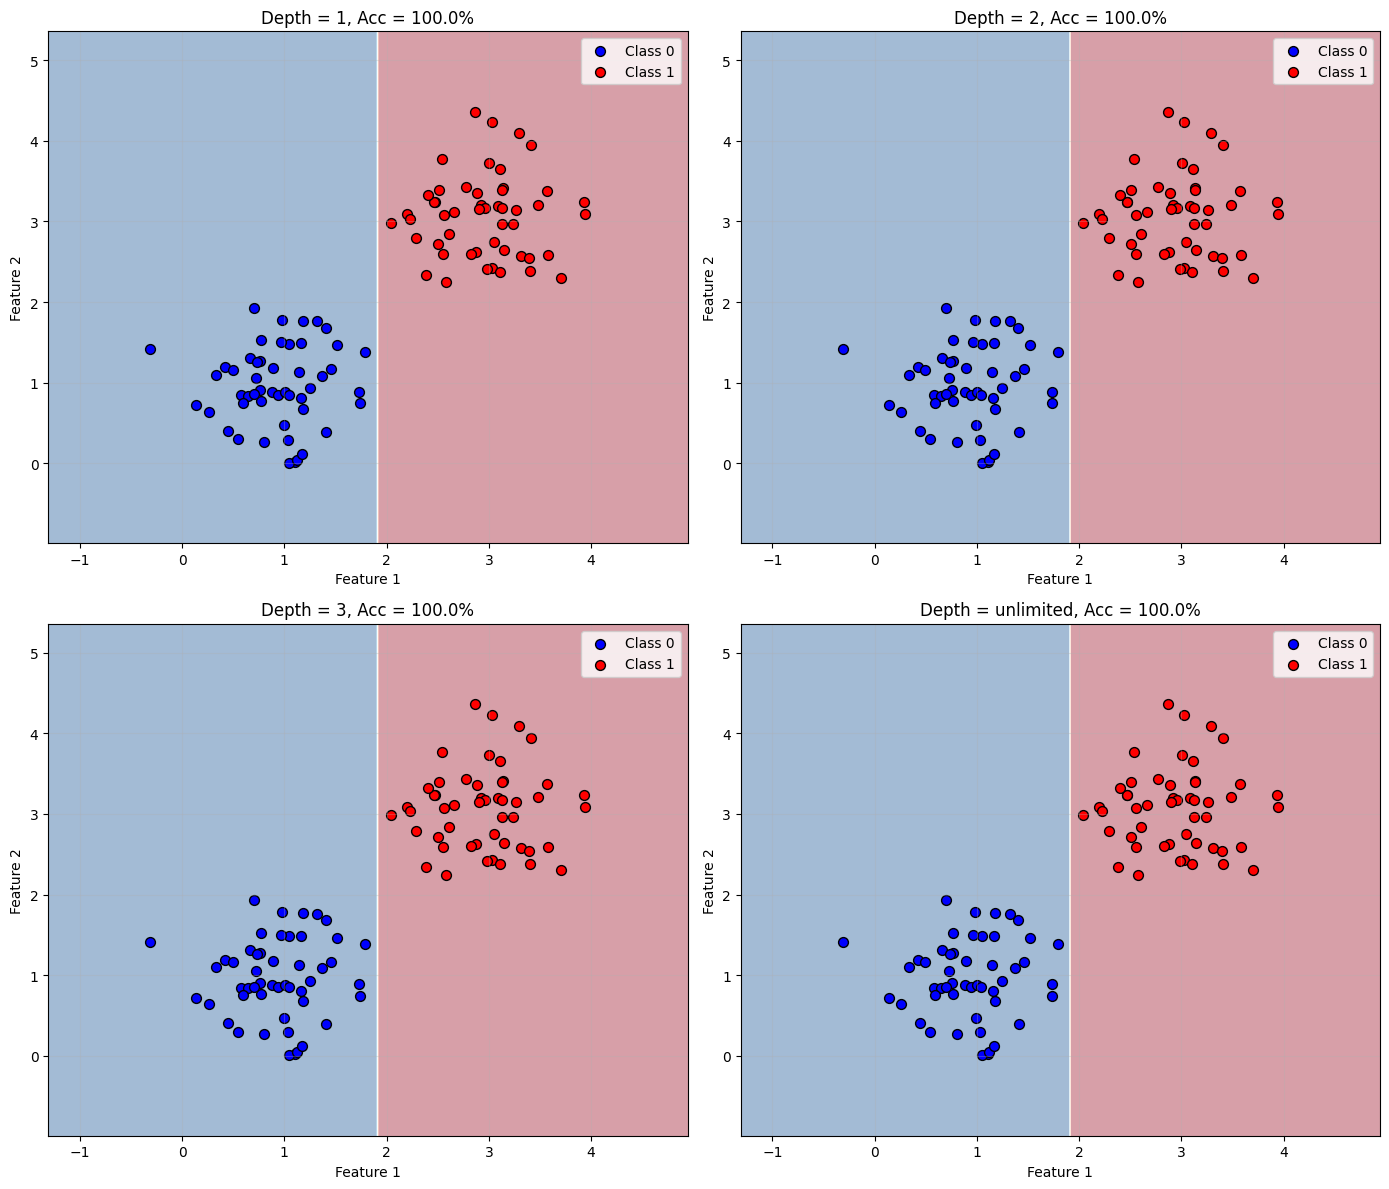


Decision Tree Test Complete!
All plots look the same because depth=1 already solves this easy data!


In [14]:
# ============================================================
# TESTING ON A SIMPLE (LINEARLY SEPARABLE) DATASET
# ============================================================
# Class 0: clustered around (1, 1)  — bottom-left
# Class 1: clustered around (3, 3)  — top-right
#
# These two clusters are far apart, so a SINGLE vertical cut
# at x~2 already separates them perfectly.
# That is why ALL depths give 100% accuracy and look the same!
#
# The NEXT cell uses an XOR dataset that actually needs
# multiple splits to show interesting depth differences.
# ============================================================

print('\n' + '=' * 60)
print('Testing Decision Tree on 2D Dataset')
print('=' * 60)

np.random.seed(42)

# Class 0: 50 points near (1, 1) with small Gaussian noise
X_class0 = np.random.randn(50, 2) * 0.5 + np.array([1, 1])
y_class0 = np.zeros(50)

# Class 1: 50 points near (3, 3) with small Gaussian noise
X_class1 = np.random.randn(50, 2) * 0.5 + np.array([3, 3])
y_class1 = np.ones(50)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])   # Stack rows -> (100, 2)
y = np.hstack([y_class0, y_class1])   # Concatenate -> (100,)
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

print(f'Dataset: {len(X)} examples, 2 features')
print(f'Class 0: {int(np.sum(y==0))} examples')
print(f'Class 1: {int(np.sum(y==1))} examples')

# ============================================================
# Train at depths 1, 2, 3, unlimited and plot boundaries
# ============================================================

depths = [1, 2, 3, None]  # None = unlimited depth

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Turn 2x2 grid into a flat list of 4 axes

for idx, max_depth in enumerate(depths):

    # Train a fresh tree
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X, y)

    # Measure accuracy on training data
    y_pred = tree.predict(X)
    accuracy = np.mean(y_pred == y) * 100

    print(f'\nDepth = {max_depth if max_depth else "unlimited"}:')
    print(f'Accuracy: {accuracy:.1f}%')

    if max_depth and max_depth <= 2:
        print('Tree structure:')
        tree.print_tree()

    # ---- Visualise the decision boundary ----
    ax = axes[idx]

    # Build a dense grid covering the feature space
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    # Predict every point on the grid to colour regions
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')  # Colour background
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, edgecolors='black', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red',  s=50, edgecolors='black', label='Class 1')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth = {max_depth if max_depth else "unlimited"}, Acc = {accuracy:.1f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDecision Tree Test Complete!')
print('All plots look the same because depth=1 already solves this easy data!')


Testing Decision Tree on XOR Dataset
Dataset: 200 examples, 2 features
Class 0: 100 | Class 1: 100
XOR pattern: depth=1 gets ~50%, needs depth=2+ to separate!

Depth = 1: Accuracy = 52.0%
Tree structure:
Feature 0 <= 3.203?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 2: Accuracy = 52.5%
Tree structure:
Feature 0 <= 3.203?
|-- True (YES):
  Feature 1 <= -2.644?
  |-- True (YES):
    Leaf: class = 0.0
  |-- False (NO):
    Leaf: class = 1.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 3: Accuracy = 59.5%
Depth = unlimited: Accuracy = 100.0%


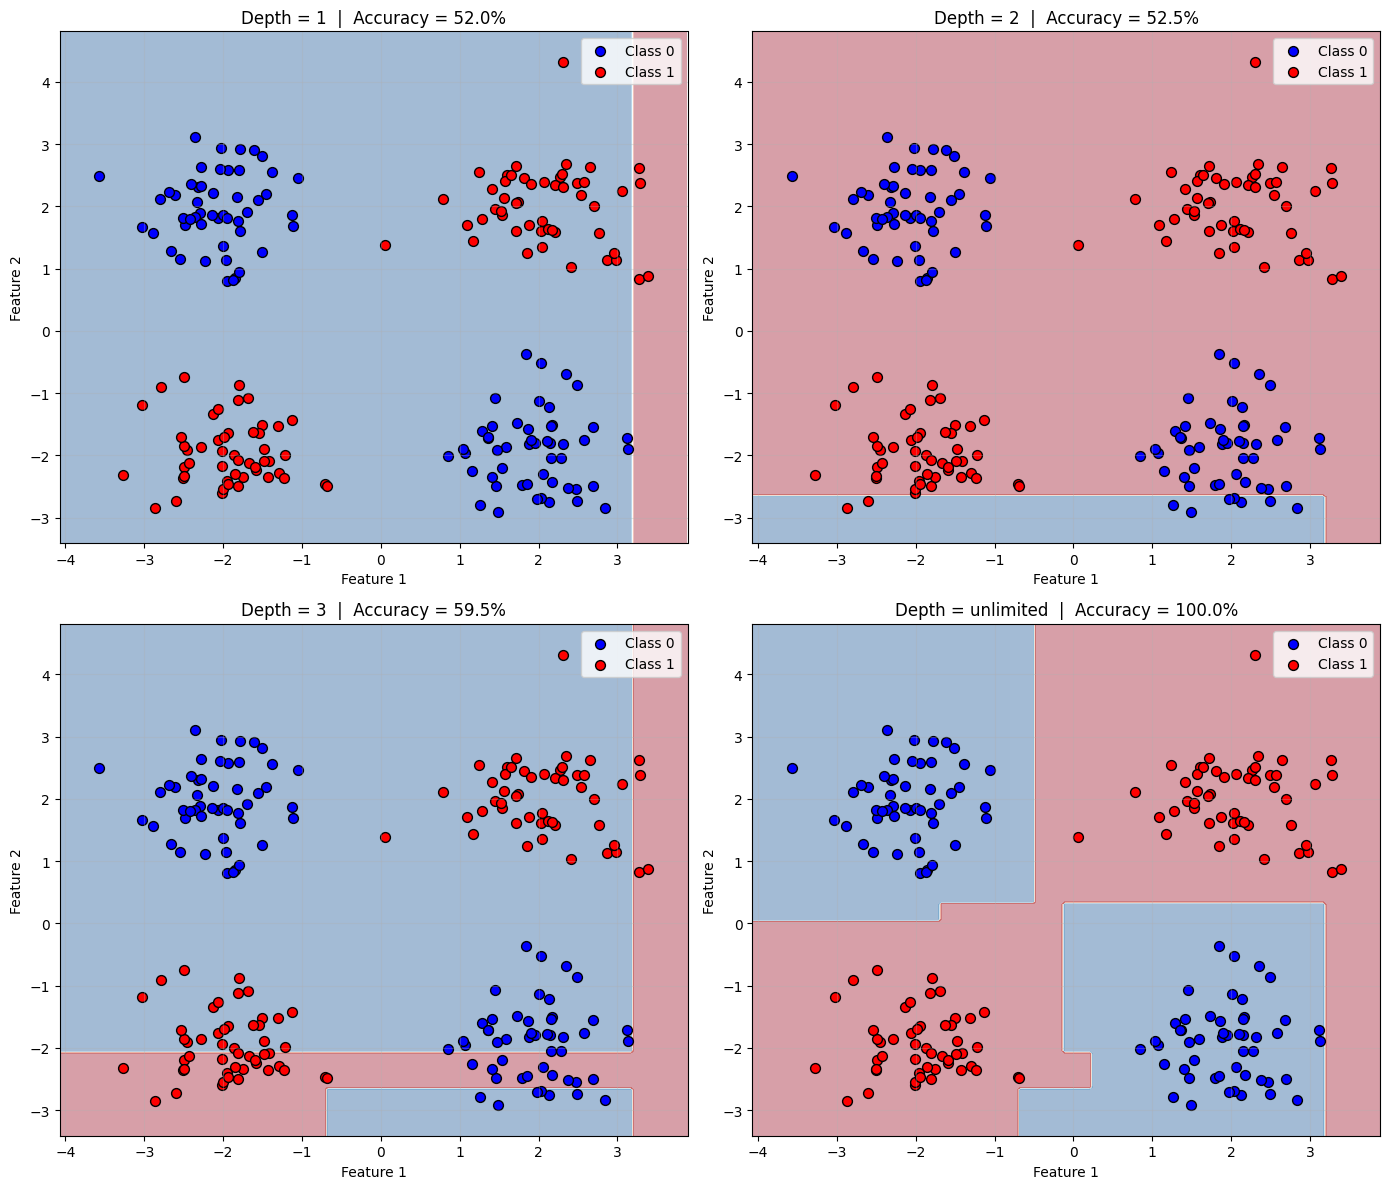


Decision Tree Test Complete!


In [15]:
# ============================================================
# TESTING ON AN XOR DATASET (requires depth >= 2)
# ============================================================
# XOR = Exclusive OR. The pattern looks like a checkerboard:
#
#   Feature 2
#     ^
#   + | [0][0] | [1][1]
#     | [0][0] | [1][1]
#   0 |---------+-------->  Feature 1
#     | [1][1] | [0][0]
#   - | [1][1] | [0][0]
#
# Class 0: top-left  + bottom-right quadrants
# Class 1: top-right + bottom-left  quadrants
#
# WHY IS THIS HARD?
#   Depth=1 makes ONE cut (left/right OR up/down)
#   -> Both halves still contain both classes -> ~50% accuracy
#
#   Depth=2 makes TWO cuts (a cross shape)
#   -> Each quadrant is now pure -> ~100% accuracy
#
# This is a great demo of WHY depth matters!
# ============================================================

np.random.seed(42)

print('=' * 60)
print('Testing Decision Tree on XOR Dataset')
print('=' * 60)

n = 50  # Points per cluster

# Class 0: top-left and bottom-right (opposite corners)
X0a = np.random.randn(n, 2) * 0.6 + np.array([-2,  2])  # top-left
X0b = np.random.randn(n, 2) * 0.6 + np.array([ 2, -2])  # bottom-right

# Class 1: top-right and bottom-left (other two corners)
X1a = np.random.randn(n, 2) * 0.6 + np.array([ 2,  2])  # top-right
X1b = np.random.randn(n, 2) * 0.6 + np.array([-2, -2])  # bottom-left

# Combine all 4 clusters: 200 examples total
X = np.vstack([X0a, X0b, X1a, X1b])
y = np.hstack([np.zeros(n * 2), np.ones(n * 2)])  # 100 class-0, 100 class-1

# Shuffle so classes are mixed in order
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

print(f'Dataset: {len(X)} examples, 2 features')
print(f'Class 0: {int(np.sum(y==0))} | Class 1: {int(np.sum(y==1))}')
print('XOR pattern: depth=1 gets ~50%, needs depth=2+ to separate!\n')

# ============================================================
# Train at depths 1, 2, 3, unlimited and compare
# ============================================================

depths = [1, 2, 3, None]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, max_depth in enumerate(depths):

    # Train tree
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X, y)

    y_pred = tree.predict(X)
    accuracy = np.mean(y_pred == y) * 100

    label = str(max_depth) if max_depth else 'unlimited'
    print(f'Depth = {label}: Accuracy = {accuracy:.1f}%')

    # Print the tree structure for shallow trees so we can read it
    if max_depth and max_depth <= 2:
        print('Tree structure:')
        tree.print_tree()
        print()

    # ---- Visualise decision boundary ----
    ax = axes[idx]
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    # Colour every grid point by predicted class
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, edgecolors='black', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red',  s=50, edgecolors='black', label='Class 1')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth = {label}  |  Accuracy = {accuracy:.1f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDecision Tree Test Complete!')

# ============================================================
# KEY TAKEAWAYS FROM THIS NOTEBOOK:
# ============================================================
# 1. Decision Trees ask yes/no questions to classify data
#
# 2. ENTROPY & GINI measure how mixed (impure) a group is
#    0 = pure (all one class), higher = more mixed
#
# 3. INFORMATION GAIN picks the best split at each node
#    Always choose the split that reduces impurity the most
#
# 4. The tree is built RECURSIVELY, splitting until:
#    - Node is pure, OR max depth reached, OR gain = 0
#
# 5. DEPTH controls complexity:
#    - Too shallow -> underfit (misses patterns)
#    - Too deep    -> overfit  (memorises training data)
#
# 6. Some patterns (like XOR) need depth >= 2 to solve
# ============================================================



Better Dataset: Showing Depth Effect
Training: 140 examples
Test:     60 examples

Depth = 1:
  Train accuracy: 90.7%
  Test accuracy:  86.7%
  Gap: 4.0%  <- should be small!

Depth = 2:
  Train accuracy: 92.1%
  Test accuracy:  86.7%
  Gap: 5.5%  <- should be small!

Depth = 3:
  Train accuracy: 95.7%
  Test accuracy:  91.7%
  Gap: 4.0%  <- should be small!

Depth = 5:
  Train accuracy: 97.9%
  Test accuracy:  91.7%
  Gap: 6.2%  <- should be small!

Depth = 10:
  Train accuracy: 100.0%
  Test accuracy:  90.0%
  Gap: 10.0%  <- should be small!

Depth = unlimited:
  Train accuracy: 100.0%
  Test accuracy:  90.0%
  Gap: 10.0%  <- should be small!


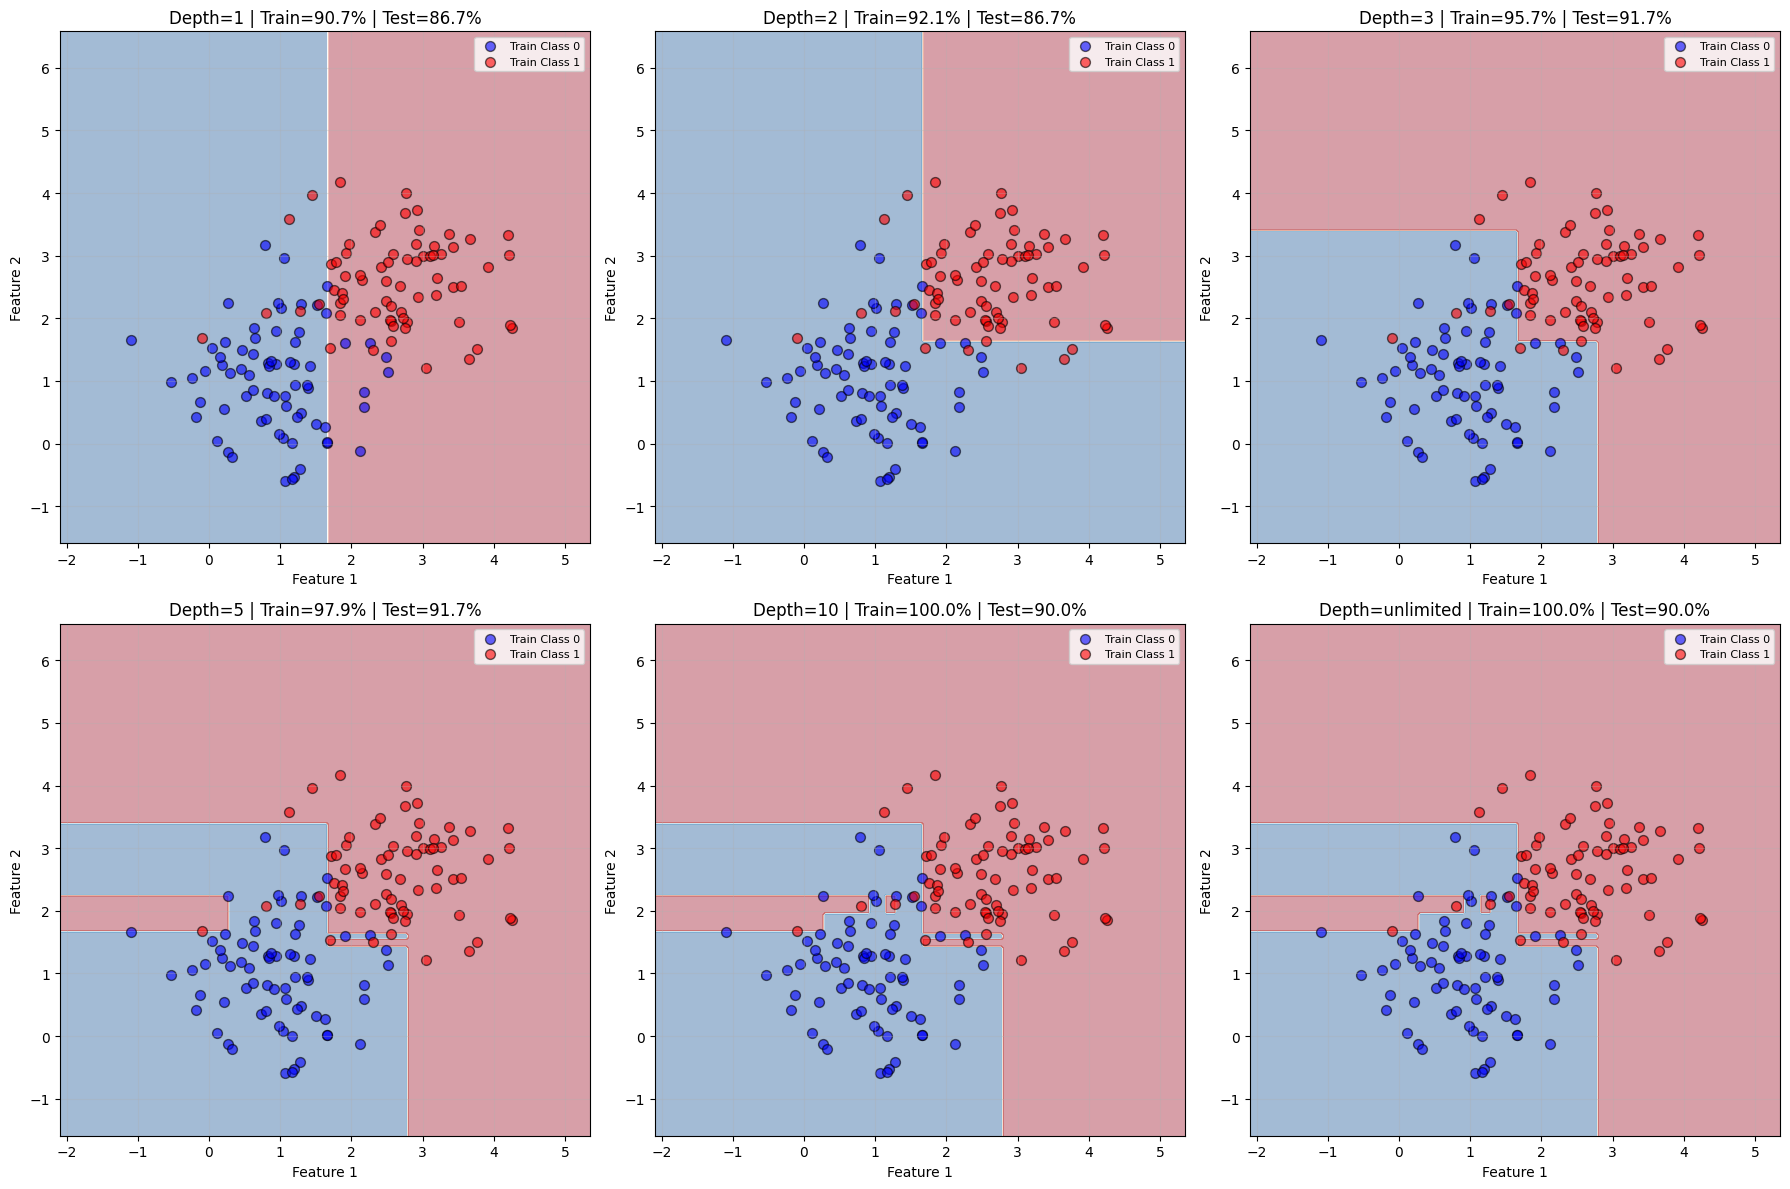

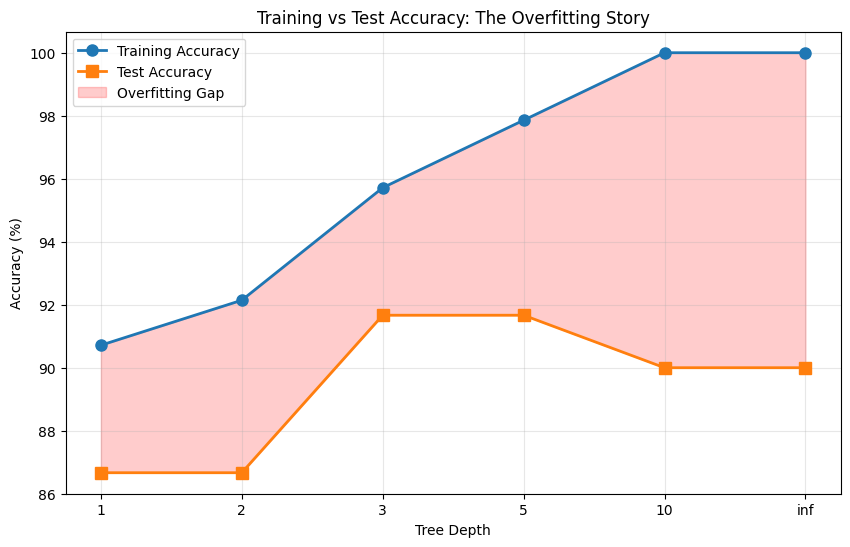


Key Observation:
As depth increases:
  Training accuracy goes UP   (memorizing training data)
  Test accuracy PEAKS then DOWN (overfitting to noise)
  The GAP between them WIDENS   (overfitting signature)

Optimal depth = where TEST accuracy is highest!


In [16]:
# ============================================================
# OVERFITTING: THE DANGER OF TREES THAT ARE TOO DEEP
# ============================================================
# So far our trees got 100% accuracy — that sounds great!
# But 100% on TRAINING data doesn't mean the model is good.
#
# THE PROBLEM: OVERFITTING
# A very deep tree can memorize every training example,
# including the random noise. It gets 100% train accuracy
# but fails badly on new, unseen data.
#
# ANALOGY:
# Imagine studying for an exam by memorizing the answers
# to every practice question EXACTLY.
# You'd ace the practice test, but fail the real exam
# because you memorized, not learned!
#
# THE SOLUTION: Train/Test Split
# - TRAINING set: used to build the tree
# - TEST set:     held out, never seen during training
#                 simulates "real world" new data
#
# A good model has SIMILAR train and test accuracy.
# A bad (overfit) model has HIGH train but LOW test accuracy.
#
# ASCII Diagram of overfitting vs. good fit:
#
#   Accuracy
#     ^
#  100|----[Train]----            <- Overfit: memorized training
#     |
#   85|         [Test]
#     |
#   90|----[Train]----[Test]----  <- Good fit: generalizes well
#     |
#     +---depth 1--depth 5--depth 10-->
# ============================================================

print("\n" + "=" * 60)
print("Better Dataset: Showing Depth Effect")
print("=" * 60)

np.random.seed(42)

# ============================================================
# STEP 1: CREATE OVERLAPPING CLUSTERS
# ============================================================
# Unlike before, these clusters are CLOSE TOGETHER and overlap.
# This means no single cut gives 100% accuracy —
# deeper trees are tempted to overfit the noise!
#
# Class 0: centered at (1.0, 1.0)   with spread = 0.8
# Class 1: centered at (2.5, 2.5)   with spread = 0.8
#
# They overlap in the middle -> some points are ambiguous!
# ============================================================

X_class0 = np.random.randn(100, 2) * 0.8 + np.array([1, 1])
y_class0 = np.zeros(100)

X_class1 = np.random.randn(100, 2) * 0.8 + np.array([2.5, 2.5])
y_class1 = np.ones(100)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])
y = np.hstack([y_class0, y_class1])
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

# ============================================================
# STEP 2: TRAIN / TEST SPLIT
# ============================================================
# We split data into:
#   70% Training  -> tree sees this during fit()
#   30% Test      -> tree NEVER sees this; used only for eval
#
# train_test_split from sklearn handles this cleanly.
# random_state=42 makes the split reproducible.
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {len(X_train)} examples")
print(f"Test:     {len(X_test)} examples")

# ============================================================
# STEP 3: TRAIN TREES AT MANY DEPTHS
# ============================================================
# We test depths [1, 2, 3, 5, 10, unlimited].
#
# What to expect:
#   Depth 1:   Very simple, one cut -> low train AND test acc
#   Depth 2-3: Reasonable fit       -> good train AND test acc
#   Depth 10+: Memorises training   -> 100% train, LOW test acc
#
# The "sweet spot" is the depth where TEST accuracy peaks!
# ============================================================

depths = [1, 2, 3, 5, 10, None]  # None = unlimited depth

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # 2x3 grid -> flat list of 6 axes

# Lists to track accuracy at each depth for the summary plot
train_accs = []
test_accs = []

for idx, max_depth in enumerate(depths):

    # Train a fresh tree using ONLY training data
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X_train, y_train)

    # Evaluate on BOTH sets
    y_train_pred = tree.predict(X_train)
    y_test_pred  = tree.predict(X_test)

    # Accuracy = fraction of correct predictions
    train_acc = np.mean(y_train_pred == y_train) * 100
    test_acc  = np.mean(y_test_pred  == y_test)  * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Print the train-test gap (key overfitting indicator!)
    label = max_depth if max_depth else 'unlimited'
    print(f"\nDepth = {label}:")
    print(f"  Train accuracy: {train_acc:.1f}%")
    print(f"  Test accuracy:  {test_acc:.1f}%")
    print(f"  Gap: {train_acc - test_acc:.1f}%  <- should be small!")

    # ---- Visualise decision boundary ----
    ax = axes[idx]

    # Dense grid to colour the background by predicted class
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')

    # Only plot TRAINING points — these are what the tree learned from
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               c='blue', s=50, edgecolors='black', alpha=0.6, label='Train Class 0')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               c='red', s=50, edgecolors='black', alpha=0.6, label='Train Class 1')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth={label} | Train={train_acc:.1f}% | Test={test_acc:.1f}%')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: PLOT THE OVERFITTING CURVE
# ============================================================
# This is the most important plot — it shows the classic
# bias-variance tradeoff:
#
#   Accuracy
#     ^
#  100|  Train ......................
#     |                           .
#   90|         Test ----         .
#     |        /         \        .
#   80|       /           \       .
#     |      /             \......
#     +--1---2---3---5---10---inf-->
#               Depth
#
# Train accuracy keeps rising (tree memorizes more).
# Test accuracy rises, peaks, then falls (overfitting!).
# The RED shaded area between them = the overfitting gap.
#
# The depth where TEST accuracy peaks = optimal depth!
# ============================================================

plt.figure(figsize=(10, 6))
depth_labels = [str(d) if d else 'inf' for d in depths]
x_pos = range(len(depths))

# Plot both lines
plt.plot(x_pos, train_accs, 'o-', linewidth=2, markersize=8, label='Training Accuracy')
plt.plot(x_pos, test_accs,  's-', linewidth=2, markersize=8, label='Test Accuracy')

# Shade the gap between train and test (the overfitting zone)
plt.fill_between(x_pos, train_accs, test_accs,
                 alpha=0.2, color='red', label='Overfitting Gap')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Test Accuracy: The Overfitting Story')
plt.xticks(x_pos, depth_labels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("Key Observation:")
print("=" * 60)
print("As depth increases:")
print("  Training accuracy goes UP   (memorizing training data)")
print("  Test accuracy PEAKS then DOWN (overfitting to noise)")
print("  The GAP between them WIDENS   (overfitting signature)")
print("\nOptimal depth = where TEST accuracy is highest!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. ALWAYS evaluate on a held-out test set — never just training!
#
# 2. High train accuracy + low test accuracy = OVERFITTING
#    The model memorized instead of learning general patterns
#
# 3. Low train AND test accuracy = UNDERFITTING
#    The model is too simple to capture the pattern
#
# 4. The BIAS-VARIANCE TRADEOFF:
#    - Shallow tree (high bias, low variance):  underfits
#    - Deep tree   (low bias, high variance):   overfits
#    - Just right:                              generalizes!
#
# 5. Use a train/test split (or cross-validation) to find
#    the optimal depth for your specific dataset
# ============================================================
